Importações e Configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline
sns.set_theme(style="whitegrid")

Carga e Divisão dos Dados

In [2]:
# Carregando os dados
df = pd.read_csv('../data/water_potability.csv')

# Separando Features e Target
X = df.drop('Potability', axis=1)
y = df['Potability']

# Divisão Treino e Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (2620, 9)
Teste: (656, 9)


Pipeline de Pré-processamento

In [3]:
# Criando o pipeline de transformação
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Mediana é mais robusta a outliers
    ('scaler', StandardScaler())
])

Comparação de Modelos (Spot-Checking)

In [4]:
models = [
    ('Logistic Regression', LogisticRegression()),
    ('SVC', SVC(probability=True)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42))
]

results = []
for name, model in models:
    # Criando um pipeline completo para cada modelo
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1')
    results.append((name, cv_scores.mean()))

# Visualizando a comparação
comparison_df = pd.DataFrame(results, columns=['Model', 'F1-Score Mean']).sort_values(by='F1-Score Mean', ascending=False)
print(comparison_df)

                 Model  F1-Score Mean
2        Random Forest       0.445469
1                  SVC       0.431413
0  Logistic Regression       0.001951


Treinamento e Avaliação do Modelo Final (Random Forest)

In [5]:
# Pipeline final com o melhor modelo
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

# Relatório de Classificação
print("--- Relatório de Performance ---")
print(classification_report(y_test, y_pred))

--- Relatório de Performance ---
              precision    recall  f1-score   support

           0       0.67      0.89      0.76       400
           1       0.64      0.30      0.41       256

    accuracy                           0.66       656
   macro avg       0.66      0.60      0.59       656
weighted avg       0.66      0.66      0.63       656



Matriz de Confusão e Importância das Variáveis

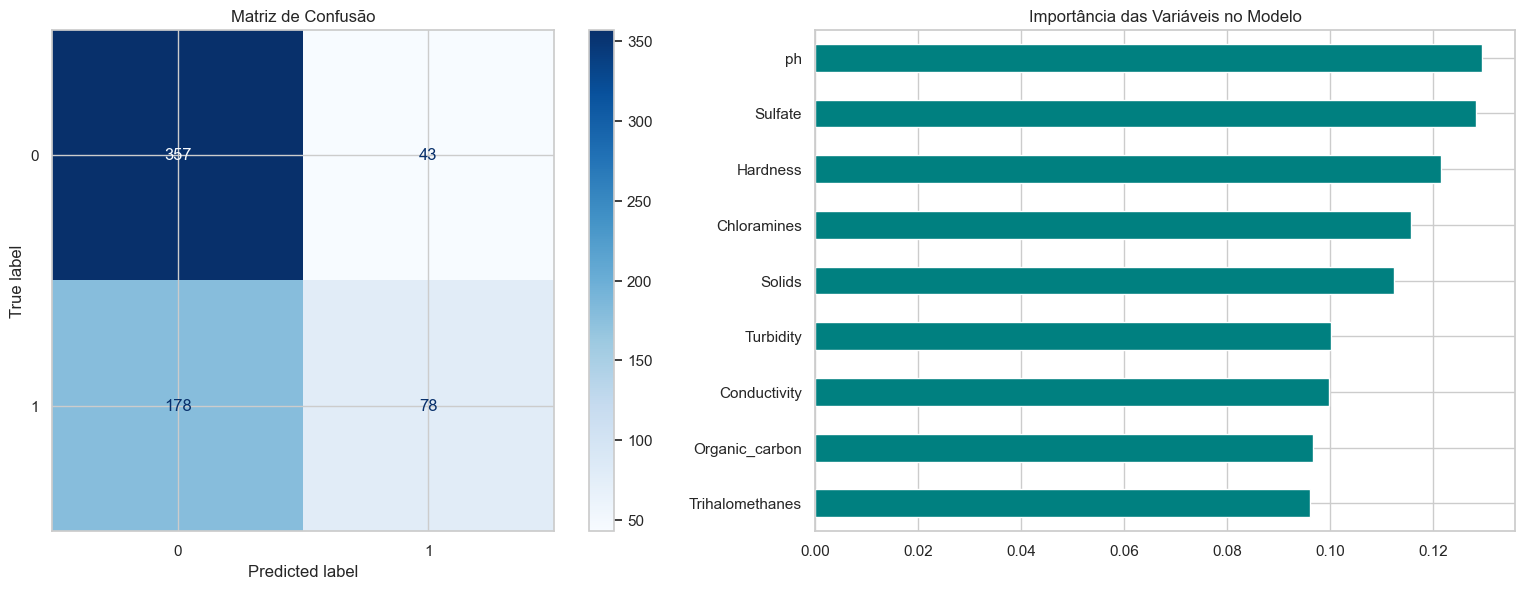

In [6]:
# Plotando a Matriz de Confusão
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test, cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusão')

# Importância das Features
importances = final_model.named_steps['classifier'].feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=ax[1], color='teal')
ax[1].set_title('Importância das Variáveis no Modelo')

plt.tight_layout()
plt.show()